# Modeling

## 1. Load Libraries

In [1]:
# !python -m spacy download en_core_web_sm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import os
import string
import spacy
import networkx as nx
import random

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
from wordcloud import WordCloud
from itertools import combinations
from spacy.lang.es.stop_words import STOP_WORDS

In [3]:
nlp = spacy.load("en_core_web_sm")

#

## 2. Load data

In [4]:
df = pd.read_csv("../data/labels.csv")

In [5]:
folder_path = "../data/articles/"

In [6]:
files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]

In [7]:
article_data = []
for file in files:
    with open(os.path.join(folder_path, file), "r", encoding="utf-8") as f:
        content = f.read()
        article_data.append(content)

In [8]:
df.insert(1, "news", article_data)

## 3. Preprocessing

¿Cuál es el sentimiento del artículo de noticias?
¿Es la noticia negativa?
¿Es la noticia positiva?
¿Es la noticia neutra?


In [9]:
df.head()

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,policy_prescription_and_evaluation,crime_and_punishment,security_and_defense,health_and_safety,quality_of_life,cultural_identity,public_opinion,political,external_regulation_and_reputation
0,Noticia_1.txt,¿Cuánto tiempo estoy autorizado a permanecer e...,"['external_regulation_and_reputation', 'legali...",neutral,legality_constitutionality_and_jurisprudence,0,0,0,0,1,1,1,0,0,0,0,0,0,1
1,Noticia_2.txt,Colombia y Venezuela instalaron comisión de ve...,"['policy_prescription_and_evaluation', 'politi...",neutral,political,1,0,1,0,0,1,0,0,0,0,0,1,1,1
2,Noticia_7.txt,"Atrasar proceso electoral hasta enero de 2024,...","['political', 'quality_of_life', 'public_opini...",neutral,political,0,0,0,0,0,0,0,0,0,1,0,1,1,0
3,Noticia_8.txt,Avanza SLP en cuanto a transparencia presupues...,"['policy_prescription_and_evaluation', 'public...",neutral,policy_prescription_and_evaluation,0,0,0,0,0,1,0,0,0,0,0,1,0,1
4,Noticia_9.txt,Confía dirigente del PT en mantener el registr...,"['external_regulation_and_reputation', 'qualit...",negative,fairness_and_equality,0,1,0,1,0,1,0,0,0,1,0,1,0,1


In [10]:
plantillas_tono = [
    "¿Cómo describirías el tono de esta noticia?",
    "¿Qué tono tiene el autor al escribir esta noticia?",
    "¿Cuál es la actitud del autor en esta noticia?",
    "¿Qué tipo de tono predomina en este texto?",
    "¿Cómo es el sentimiento general de esta noticia?",
    "¿Qué percepción transmite el tono de la noticia?",
    "¿Qué emoción o tono se refleja en esta noticia?",
    "¿Cuál es la intención emocional del autor?",
    "¿Qué sentimiento evoca esta noticia?",
]

# Generar pregunta y respuesta basada SOLO en el tono
def generar_qa_tono_puro(row):
    pregunta = random.choice(plantillas_tono)
    respuesta = row['tone']

    return pd.Series({'question': pregunta, 'answer': respuesta})

# Aplicar a todo el dataframe
df[['question', 'answer']] = df.apply(generar_qa_tono_puro, axis=1)


In [11]:
import pandas as pd
import random

# Plantillas de preguntas por tipo de tono
plantillas_tono = {
    "Neutral": [
        "¿Qué tono tiene esta noticia?",
        "¿Cómo es el tono de esta información?",
        "¿Cuál es el tono principal en esta noticia neutral?",
        "¿Qué tipo de tono presenta esta noticia?",
        "¿Se percibe un tono neutral en el texto?"
    ],
    "Positive": [
        "¿El tono de esta noticia es positivo, negativo o neutral?",
        "¿Qué tipo de tono alegre o esperanzador tiene esta noticia?",
        "¿Cómo describirías el tono optimista de esta noticia?",
        "¿Qué tono positivo refleja este texto?",
        "¿Qué tipo de sentimiento positivo transmite esta noticia?"
    ],
    "Negative": [
        "¿Qué tipo de tono crítico o negativo tiene esta noticia?",
        "¿Cómo describirías el tono preocupante de esta noticia?",
        "¿Qué tono pesimista o negativo transmite esta noticia?",
        "¿Se percibe un tono negativo en este texto?",
        "¿Cuál es el tono dramático o triste en esta noticia?"
    ]
}

# Función para generar QA centrado en tono
def generar_qa_tono(row):
    tono = row['tone']  # Neutral, Positive, Negative
    pregunta = random.choice(plantillas_tono.get(tono, ["¿Qué tono tiene esta noticia?"]))
    respuesta = tono
    return pd.Series({'question': pregunta, 'answer': respuesta})

# Aplicar a tu dataframe
df[['question1', 'answer1']] = df.apply(generar_qa_tono, axis=1)

# Exportar
df.to_csv("dataset_QA_tono_puro_final.csv", index=False)

In [12]:
df.head()

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,...,health_and_safety,quality_of_life,cultural_identity,public_opinion,political,external_regulation_and_reputation,question,answer,question1,answer1
0,Noticia_1.txt,¿Cuánto tiempo estoy autorizado a permanecer e...,"['external_regulation_and_reputation', 'legali...",neutral,legality_constitutionality_and_jurisprudence,0,0,0,0,1,...,0,0,0,0,0,1,¿Qué tipo de tono predomina en este texto?,neutral,¿Qué tono tiene esta noticia?,neutral
1,Noticia_2.txt,Colombia y Venezuela instalaron comisión de ve...,"['policy_prescription_and_evaluation', 'politi...",neutral,political,1,0,1,0,0,...,0,0,0,1,1,1,¿Qué emoción o tono se refleja en esta noticia?,neutral,¿Qué tono tiene esta noticia?,neutral
2,Noticia_7.txt,"Atrasar proceso electoral hasta enero de 2024,...","['political', 'quality_of_life', 'public_opini...",neutral,political,0,0,0,0,0,...,0,1,0,1,1,0,¿Qué tipo de tono predomina en este texto?,neutral,¿Qué tono tiene esta noticia?,neutral
3,Noticia_8.txt,Avanza SLP en cuanto a transparencia presupues...,"['policy_prescription_and_evaluation', 'public...",neutral,policy_prescription_and_evaluation,0,0,0,0,0,...,0,0,0,1,0,1,¿Qué tono tiene el autor al escribir esta noti...,neutral,¿Qué tono tiene esta noticia?,neutral
4,Noticia_9.txt,Confía dirigente del PT en mantener el registr...,"['external_regulation_and_reputation', 'qualit...",negative,fairness_and_equality,0,1,0,1,0,...,0,1,0,1,0,1,¿Cómo es el sentimiento general de esta noticia?,negative,¿Qué tono tiene esta noticia?,negative


In [13]:
df.tail()

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,...,health_and_safety,quality_of_life,cultural_identity,public_opinion,political,external_regulation_and_reputation,question,answer,question1,answer1
135,Noticia_120.txt,Vacaciones de terror: agencia de viajes poblan...,"['public_opinion', 'political', 'quality_of_li...",neutral,political,0,0,0,0,0,...,0,1,0,1,1,0,¿Qué percepción transmite el tono de la noticia?,neutral,¿Qué tono tiene esta noticia?,neutral
136,Noticia_119.txt,"En SLP, la gasolina más barata se vende por de...","['capacity_and_resources', 'economic', 'politi...",neutral,economic,1,1,0,0,0,...,0,0,0,1,1,0,¿Cuál es la actitud del autor en esta noticia?,neutral,¿Qué tono tiene esta noticia?,neutral
137,Noticia_118.txt,Inflación baja a 4.79% en la primera mitad de ...,"['security_and_defense', 'political']",positive,security_and_defense,0,0,0,0,0,...,0,0,0,0,1,0,¿Cuál es la intención emocional del autor?,positive,¿Qué tono tiene esta noticia?,positive
138,Noticia_117.txt,Reducción de jornada laboral provocará un desp...,"['security_and_defense', 'morality', 'public_o...",neutral,security_and_defense,0,0,1,0,1,...,0,1,0,1,1,0,¿Qué tono tiene el autor al escribir esta noti...,neutral,¿Qué tono tiene esta noticia?,neutral
139,Noticia_116.txt,Advierte Ricardo Gallardo más cambios en su ga...,"['policy_prescription_and_evaluation', 'public...",positive,policy_prescription_and_evaluation,0,0,0,1,0,...,0,0,0,1,1,0,¿Qué tono tiene el autor al escribir esta noti...,positive,¿Qué tono tiene esta noticia?,positive


## 3.1 Unicode

In [14]:
df["news"] = df["news"].astype(str).apply(lambda x: x.encode("utf-8").decode("utf-8"))

## 3.2 Lower

In [15]:
df["news_clean"] = df["news"].astype(str).apply(lambda x: re.sub(r"[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ ]", "", x.lower()))


## 3.3 Remove Stopwords

In [16]:
def remove_stopwords(text):
    words = text.split()  # Tokenize text by splitting on spaces
    filtered_words = [word for word in words if word not in STOP_WORDS]  # Remove stopwords
    return " ".join(filtered_words)  # Join back into a sentence

In [17]:
df["news_no_stopwords"] = df["news_clean"].apply(remove_stopwords)

## 3.4 Lemmatization or stemming

In [18]:
def lemmatize_text(text):
    doc = nlp(text)  # Process text with spaCy
    lemmas = [token.lemma_ for token in doc]  # Extract lemmas
    return " ".join(lemmas)  # Join words back into a sentence

In [19]:
df["news_lemmatized"] = df["news_no_stopwords"].apply(lemmatize_text)

## 3.5 Tokenization

In [20]:
df["news_tokenized"] = df["news_lemmatized"].apply(lambda x: [token.text for token in nlp(str(x))])

In [21]:
df["news_tokenized"].head()

0    [tiempo, autorizado, permanecer, unido, crucia...
1    [colombia, venezuela, instalaron, comisión, ve...
2    [atrasar, proceso, electoral, enero, puesto, d...
3    [avanza, slp, transparencia, presupuestal, imc...
4    [confía, dirigente, pt, mantener, registro, sa...
Name: news_tokenized, dtype: object

## Model Test

In [31]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load model & tokenizer
model_name = "tabularisai/multilingual-sentiment-analysis"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False, trust_remote_code=True, model_max_length=512)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create pipeline with truncation enabled
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, truncation=True)

Device set to use cpu


In [32]:
# Predict sentiment
df['predicted_sentiment'] = df['news'].apply(lambda x: sentiment_pipeline(str(x))[0]['label'].lower())

Accuracy: 0.38571428571428573

Classification Report:
               precision    recall  f1-score   support

    negative       0.39      0.51      0.44        55
     neutral       0.40      0.43      0.41        54
    positive       0.30      0.10      0.15        31

    accuracy                           0.39       140
   macro avg       0.36      0.34      0.33       140
weighted avg       0.37      0.39      0.36       140



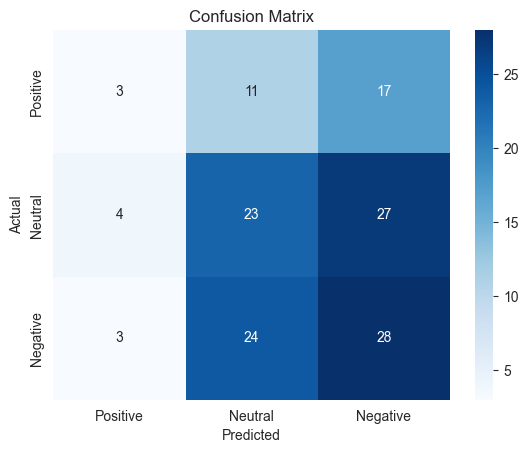

Predictions saved to output_with_predictions.csv


In [38]:
# Mapping Function
def map_label(label):
    label = label.lower()
    if 'negative' in label:
        return 'negative'
    elif 'positive' in label:
        return 'positive'
    else:
        return 'neutral'

# Predict and Map
df['predicted_sentiment'] = df['news'].apply(lambda x: map_label(sentiment_pipeline(str(x))[0]['label']))

# Evaluation
print("Accuracy:", accuracy_score(df['tone'], df['predicted_sentiment']))
print("\nClassification Report:\n", classification_report(df['tone'], df['predicted_sentiment']))

# Confusion Matrix
cm = confusion_matrix(df['tone'], df['predicted_sentiment'], labels=['positive', 'neutral', 'negative'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Positive', 'Neutral', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Save Output
df.to_csv("output_with_predictions.csv", index=False)
print("Predictions saved to output_with_predictions.csv")
